In [1]:
import pickle

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso

from sklearn.metrics import root_mean_squared_error

import mlflow
import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

/home/codespace/.python/current/lib/python3.12/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
DB_PATH = "/workspaces/mlops-zoomcamp/02-experiment-tracking/mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{DB_PATH}")
mlflow.set_experiment("duration-prediction")

<Experiment: artifact_location='/workspaces/mlops-zoomcamp/02-experiment-tracking/mlruns/1', creation_time=1776061263776, experiment_id='1', last_update_time=1776061263776, lifecycle_stage='active', name='duration-prediction', tags={}, trace_location=None, workspace='default'>

In [3]:
## mlflow ui command
# mlflow ui --backend-store-uri sqlite:////workspaces/mlops-zoomcamp/02-experiment-tracking/mlflow.db

In [4]:
jan_file = '../data/green_tripdata_2021-01.parquet'
feb_file = '../data/green_tripdata_2021-02.parquet'

# Baseline with MLFlow

In [5]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)

    return df

In [6]:
df_train = read_dataframe(jan_file)
df_val = read_dataframe(feb_file)

In [7]:
len(df_train), len(df_val)

(73908, 61921)

In [8]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [9]:
categorical = ['PU_DO'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)


In [10]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

In [11]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.758715209092169

In [12]:
with mlflow.start_run():

    mlflow.set_tag("developer", "kai")

    mlflow.log_param("train-data-path", jan_file)
    mlflow.log_param("val-data-path", feb_file)

    alpha = 0.01

    mlflow.log_param("alpha", alpha)

    lasso = Lasso(alpha)
    lasso.fit(X_train, y_train)

    y_pred = lasso.predict(X_val)

    rmse = root_mean_squared_error(y_val, y_pred)

    mlflow.log_metric("rmse", rmse)

In [13]:
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

# Hyperparameter tuning with XGBoost and MLflow

In [18]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [15]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=100,
            evals=[(valid, 'validation')],
            early_stopping_rounds=20
        )
        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [16]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=2,
    trials=Trials()
)

  0%|          | 0/2 [00:00<?, ?trial/s, best loss=?]

/home/codespace/.python/current/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [05:47:34] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:11.52001                         
[1]	validation-rmse:10.90316                         
[2]	validation-rmse:10.35671                         
[3]	validation-rmse:9.87411                          
[4]	validation-rmse:9.44801                          
[5]	validation-rmse:9.07339                          
[6]	validation-rmse:8.74537                          
[7]	validation-rmse:8.45875                          
[8]	validation-rmse:8.20912                          
[9]	validation-rmse:7.99173                          
[10]	validation-rmse:7.80257                         
[11]	validation-rmse:7.63836                         
[12]	validation-rmse:7.49581                         
[13]	validation-rmse:7.37249                         
[14]	validation-rmse:7.26583                         
[15]	validation-rmse:7.17342                         
[16]	validation-rmse:7.09332                         
[17]	validation-rmse:7.02422                         
[18]	validation-rmse:6.96351

/home/codespace/.python/current/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [05:48:21] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()



[0]	validation-rmse:11.44522                                                  
[1]	validation-rmse:10.77420                                                  
[2]	validation-rmse:10.18929                                                  
[3]	validation-rmse:9.68250                                                   
[4]	validation-rmse:9.24392                                                   
[5]	validation-rmse:8.86578                                                   
[6]	validation-rmse:8.54290                                                   
[7]	validation-rmse:8.26545                                                   
[8]	validation-rmse:8.02792                                                   
[9]	validation-rmse:7.82614                                                   
[10]	validation-rmse:7.65280                                                  
[11]	validation-rmse:7.50768                                                  
[12]	validation-rmse:7.38286                        

# Autologging with MLflow

In [ ]:
mlflow.xgboost.autolog(disable=True) # May cause kernel to crash in codespaces

In [17]:
with mlflow.start_run():

    train = xgb.DMatrix(X_train, label=y_train)
    valid = xgb.DMatrix(X_val, label=y_val)

    best_params = {
        'learning_rate': 0.09585355369315604,
        'max_depth': 30,
        'min_child_weight': 1.060597050922164,
        'objective': 'reg:linear',
        'reg_alpha': 0.018060244040060163,
        'reg_lambda': 0.011658731377413597,
        'seed': 42
    }

    mlflow.log_params(best_params)

    booster = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=1000,
        evals=[(valid, 'validation')],
        early_stopping_rounds=50
    )

    y_pred = booster.predict(valid)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    with open("models/preprocessor.b", "wb") as f_out:
        pickle.dump(dv, f_out)
    mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow")

/home/codespace/.python/current/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning: [05:54:16] WARNING: /__w/xgboost/xgboost/src/objective/regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[0]	validation-rmse:11.44482
[1]	validation-rmse:10.77202
[2]	validation-rmse:10.18363
[3]	validation-rmse:9.67396
[4]	validation-rmse:9.23166
[5]	validation-rmse:8.84808
[6]	validation-rmse:8.51883
[7]	validation-rmse:8.23597
[8]	validation-rmse:7.99320
[9]	validation-rmse:7.78709
[10]	validation-rmse:7.61022
[11]	validation-rmse:7.45952
[12]	validation-rmse:7.33049
[13]	validation-rmse:7.22098
[14]	validation-rmse:7.12713
[15]	validation-rmse:7.04752
[16]	validation-rmse:6.98005
[17]	validation-rmse:6.92232
[18]	validation-rmse:6.87112
[19]	validation-rmse:6.82740
[20]	validation-rmse:6.78995
[21]	validation-rmse:6.75792
[22]	validation-rmse:6.72994
[23]	validation-rmse:6.70547
[24]	validation-rmse:6.68390
[25]	validation-rmse:6.66421
[26]	validation-rmse:6.64806
[27]	validation-rmse:6.63280
[28]	validation-rmse:6.61924
[29]	validation-rmse:6.60773
[30]	validation-rmse:6.59777
[31]	validation-rmse:6.58875
[32]	validation-rmse:6.58107
[33]	validation-rmse:6.57217
[34]	validation-rmse:

2026/04/17 05:58:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


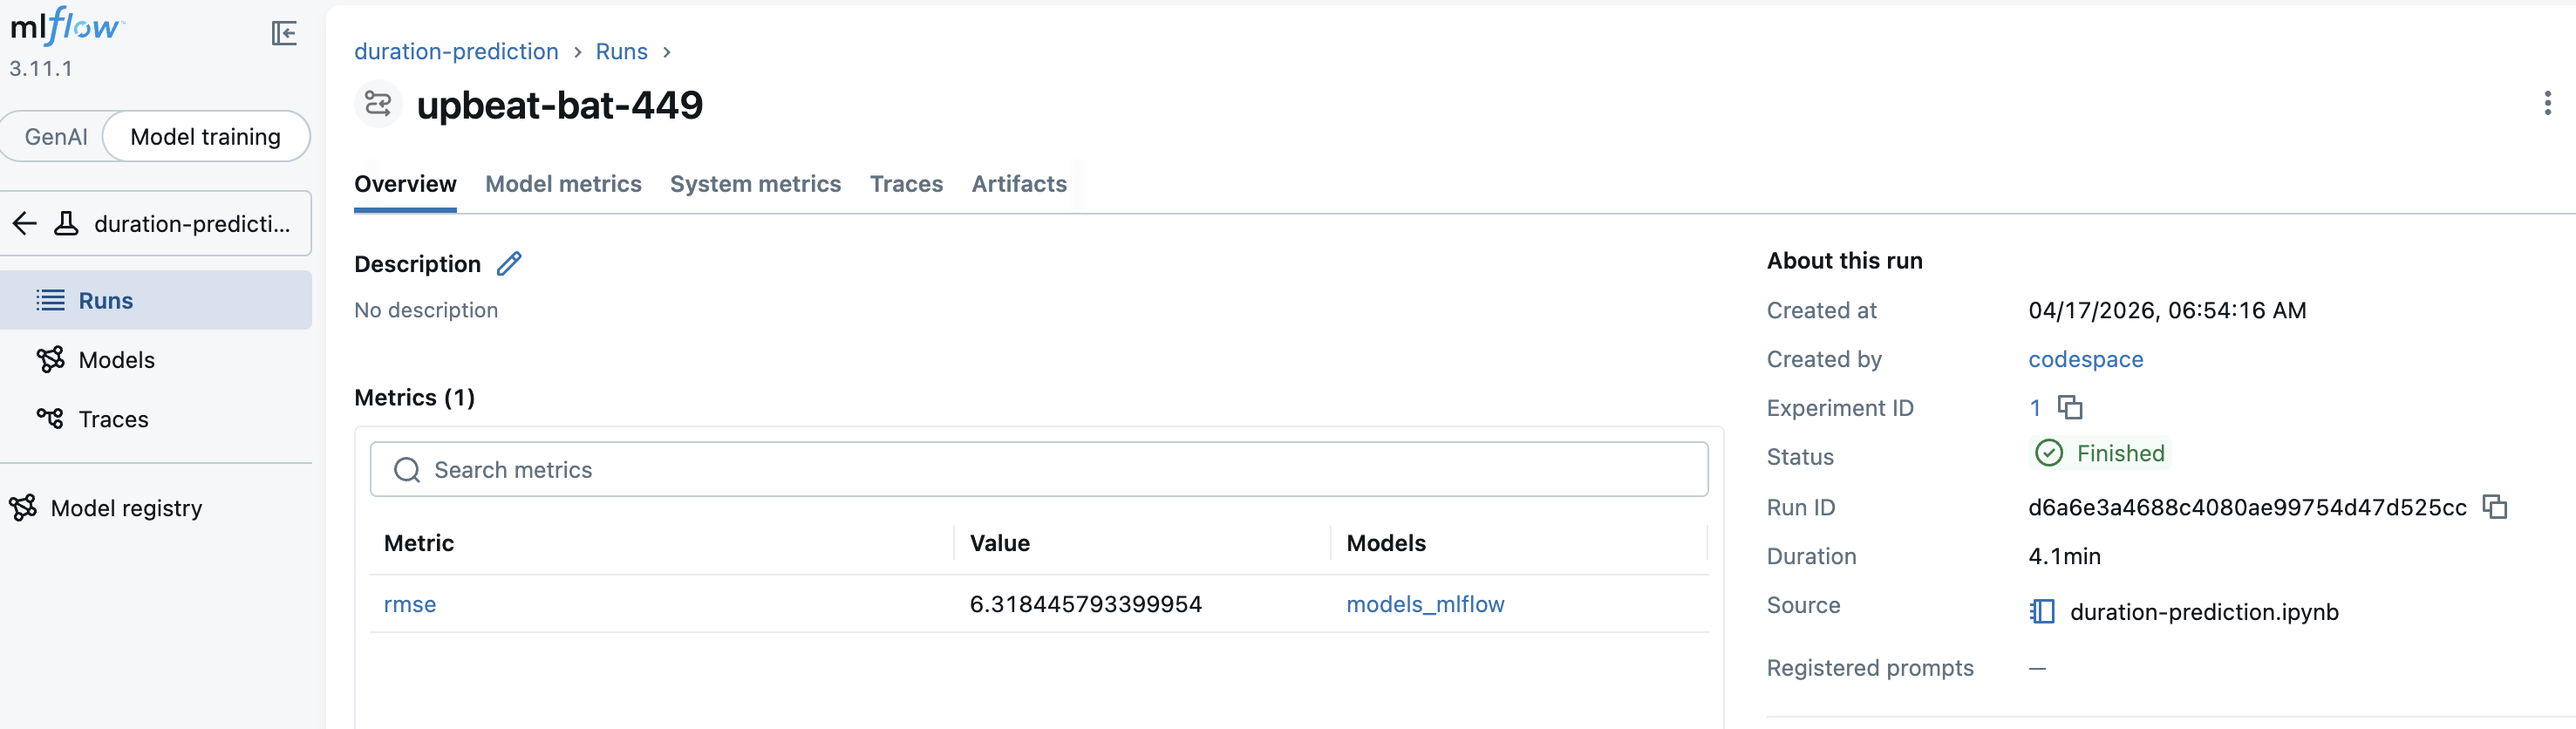

In [14]:
# load .png file
from IPython.display import Image, display

display(Image(filename="mlflow_loading_model.png"))

In [ ]:
run_id = 'd6a6e3a4688c4080ae99754d47d525cc'

# Load as pyfunc model
loaded_model = mlflow.pyfunc.load_model(f"runs:/{run_id}/models_mlflow")
loaded_model

mlflow.pyfunc.loaded_model:
  artifact_path: /workspaces/mlops-zoomcamp/02-experiment-tracking/mlruns/1/models/m-e644886a0d734b90bebf875e4a6f8305/artifacts
  flavor: mlflow.xgboost
  run_id: d6a6e3a4688c4080ae99754d47d525cc

In [16]:
loaded_model.predict(X_val)

array([14.782765 ,  7.184751 , 15.971323 , ..., 13.464008 ,  6.7352147,
        8.184539 ], shape=(61921,), dtype=float32)

In [ ]:
# Load as xgboost model
xgboost_model = mlflow.xgboost.load_model(f"runs:/{run_id}/models_mlflow")
xgboost_model.predict(valid)

array([14.782765 ,  7.184751 , 15.971323 , ..., 13.464008 ,  6.7352147,
        8.184539 ], shape=(61921,), dtype=float32)

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import LinearSVR

# mlflow.sklearn.autolog()

for model_class in (RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, LinearSVR):

    with mlflow.start_run():

        mlflow.log_param("train-data-path", "./data/green_tripdata_2021-01.csv")
        mlflow.log_param("valid-data-path", "./data/green_tripdata_2021-02.csv")
        mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")

        mlmodel = model_class()
        mlmodel.fit(X_train, y_train)

        y_pred = mlmodel.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred, squared=False)
        mlflow.log_metric("rmse", rmse)
